loads existing SN1987A_cands.csv, computes local offsets in pc, and estimates the local LMC proper motion from  Gaia sample.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.coordinates import SkyCoord, SkyOffsetFrame

from pathlib import Path

output_dir = Path("output_files")
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000

# Tegkelidis et al. 2025
sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")
pmra_87a = 1.60
pmdec_87a = 0.44
pmra_87a_err = 0.15
pmdec_87a_err = 0.09

# R136
r136 = SkyCoord(ra=84.6767920*u.deg, dec=-69.1006110*u.deg, frame="icrs")

df = pd.read_csv(output_dir / "SN1987A_cands.csv")
df.columns = df.columns.str.strip()

coords = SkyCoord(df["ra"].values*u.deg, df["dec"].values*u.deg, frame="icrs")

# Tangent-plane coordinates centred on SN1987A
frame_87a = SkyOffsetFrame(origin=sn87a)
off = coords.transform_to(frame_87a)

df["x_pc"] = off.lon.to_value(u.rad) * D_LMC_pc     # east
df["y_pc"] = off.lat.to_value(u.rad) * D_LMC_pc     # north
df["sep_87a_pc"] = np.sqrt(df["x_pc"]**2 + df["y_pc"]**2)

# R136 in the same coordinate system
r136_off = r136.transform_to(frame_87a)
x_r136_pc = r136_off.lon.to_value(u.rad) * D_LMC_pc
y_r136_pc = r136_off.lat.to_value(u.rad) * D_LMC_pc

# Absolute PM difference from SN1987A


# Estimate local LMC motion from nearby cleaned Gaia stars.
# Use the full sample if already local; otherwise use inside 100 pc.
local = df[df["sep_87a_pc"] < 100].copy()
if len(local) < 20:
    local = df.copy()

pmra_local = np.nanmedian(local["pmra"])
pmdec_local = np.nanmedian(local["pmdec"])

# Robust uncertainty on the local median.
# This is not a final statistical treatment; it is enough for an exploratory shaded region.
pmra_local_sigma = 0.5 * (np.nanpercentile(local["pmra"], 84) - np.nanpercentile(local["pmra"], 16))
pmdec_local_sigma = 0.5 * (np.nanpercentile(local["pmdec"], 84) - np.nanpercentile(local["pmdec"], 16))

pmra_local_err = 1.253 * pmra_local_sigma / np.sqrt(len(local))
pmdec_local_err = 1.253 * pmdec_local_sigma / np.sqrt(len(local))

pmra_rel_87a = pmra_87a - pmra_local
pmdec_rel_87a = pmdec_87a - pmdec_local

print("N local =", len(local))
print("Local median PMRA* =", pmra_local, "+/-", pmra_local_err, "mas/yr")
print("Local median PMDec =", pmdec_local, "+/-", pmdec_local_err, "mas/yr")
print("SN1987A residual PMRA* =", pmra_rel_87a, "mas/yr")
print("SN1987A residual PMDec =", pmdec_rel_87a, "mas/yr")

mu_rel = np.sqrt(pmra_rel_87a**2 + pmdec_rel_87a**2)
v_rel = 4.74047 * D_LMC_kpc * mu_rel
print("Residual transverse speed =", v_rel, "km/s")

N local = 648
Local median PMRA* = 1.6743033157703813 +/- 0.006070382092690554 mas/yr
Local median PMDec = 0.5571585281202223 +/- 0.004779958532014617 mas/yr
SN1987A residual PMRA* = -0.07430331577038118 mas/yr
SN1987A residual PMDec = -0.11715852812022226 mas/yr
Residual transverse speed = 32.613559499099566 km/s


C:\Users\bukow\AppData\Local\Temp\ipykernel_23956\1124684396.py:36: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["x_pc"] = off.lon.to_value(u.rad) * D_LMC_pc     # east
C:\Users\bukow\AppData\Local\Temp\ipykernel_23956\1124684396.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["y_pc"] = off.lat.to_value(u.rad) * D_LMC_pc     # north
C:\Users\bukow\AppData\Local\Temp\ipykernel_23956\1124684396.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

In [2]:
# ------------------------------------------------------------
# Unambiguous proper-motion and velocity columns
# ------------------------------------------------------------

masyr_to_kms = 4.74047 * D_LMC_kpc

# Difference between each star and the adopted SN 1987A motion
df["dpm_to_sn87a_masyr"] = np.hypot(
    df["pmra"] - pmra_87a,
    df["pmdec"] - pmdec_87a
)

df["dv_to_sn87a_kms"] = (
        masyr_to_kms * df["dpm_to_sn87a_masyr"]
)

# Difference between each star and the local LMC median
df["dpm_to_local_masyr"] = np.hypot(
    df["pmra"] - pmra_local,
    df["pmdec"] - pmdec_local
)

df["dv_to_local_kms"] = (
        masyr_to_kms * df["dpm_to_local_masyr"]
)

print("Velocity columns:")
print(df[
          [
              "dpm_to_sn87a_masyr",
              "dv_to_sn87a_kms",
              "dpm_to_local_masyr",
              "dv_to_local_kms"
          ]
      ].describe())

Velocity columns:
       dpm_to_sn87a_masyr  dv_to_sn87a_kms  dpm_to_local_masyr  \
count         1061.000000      1061.000000         1061.000000   
mean             0.215765        50.722111            0.164300   
std              0.163496        38.434668            0.155983   
min              0.001241         0.291809            0.002309   
25%              0.127676        30.014164            0.079322   
50%              0.183579        43.155651            0.128651   
75%              0.270223        63.524051            0.204779   
max              3.076895       723.316194            2.971620   

       dv_to_local_kms  
count      1061.000000  
mean         38.623649  
std          36.668529  
min           0.542813  
25%          18.647061  
50%          30.243294  
75%          48.139385  
max         698.568067  


C:\Users\bukow\AppData\Local\Temp\ipykernel_23956\132458155.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dpm_to_sn87a_masyr"] = np.hypot(
C:\Users\bukow\AppData\Local\Temp\ipykernel_23956\132458155.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dv_to_sn87a_kms"] = (
C:\Users\bukow\AppData\Local\Temp\ipykernel_23956\132458155.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

“radius that 87A could have come from” calculation and plot

below 20 km/s: very similar motion
20–30 km/s: still plausibly similar, but looser
above 30 km/s: less likely to be locally co-moving with SN1987A

,age_Myr,v_kms,radius_pc,radius_deg,radius_arcmin
0,10,10,102.27120,0.118163,7.089786
1,10,20,204.54240,0.236326,14.179572
2,10,30,306.81360,0.354489,21.269358
3,10,50,511.35600,0.590815,35.448930
4,10,100,1022.71200,1.181631,70.897860
5,12,10,122.72544,0.141796,8.507743
6,12,20,245.45088,0.283591,17.015486
7,12,30,368.17632,0.425387,25.523230
8,12,50,613.62720,0.708979,42.538716
9,12,100,1227.25440,1.417957,85.077432


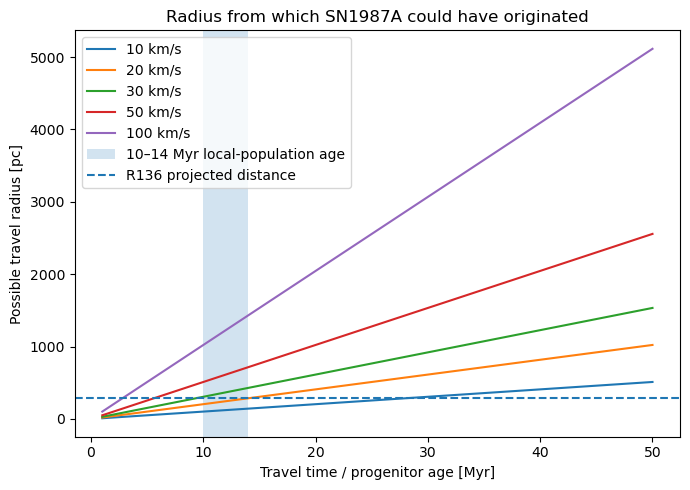

In [3]:
def travel_radius_pc(v_kms, age_myr):
    # 1 km/s = 1.022712 pc/Myr
    return v_kms * 1.022712 * age_myr

def pc_to_deg(r_pc):
    return np.degrees(r_pc / D_LMC_pc)

ages = np.array([10, 12, 14, 30, 40])
velocities = np.array([10, 20, 30, 50, 100])

rows = []
for age in ages:
    for v in velocities:
        r_pc = travel_radius_pc(v, age)
        rows.append({
            "age_Myr": age,
            "v_kms": v,
            "radius_pc": r_pc,
            "radius_deg": pc_to_deg(r_pc),
            "radius_arcmin": 60 * pc_to_deg(r_pc)
        })

reach = pd.DataFrame(rows)
display(reach)

plt.figure(figsize=(7, 5))
for v in velocities:
    ages_plot = np.linspace(1, 50, 300)
    r_plot = travel_radius_pc(v, ages_plot)
    plt.plot(ages_plot, r_plot, label=f"{v} km/s")

plt.axvspan(10, 14, alpha=0.2, label="10–14 Myr local-population age")
plt.axhline(np.sqrt(x_r136_pc**2 + y_r136_pc**2), linestyle="--", label="R136 projected distance")
plt.xlabel("Travel time / progenitor age [Myr]")
plt.ylabel("Possible travel radius [pc]")
plt.title("Radius from which SN1987A could have originated")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "origin_radius_vs_age.png", dpi=300)
plt.show()

main sky plot with reach circles

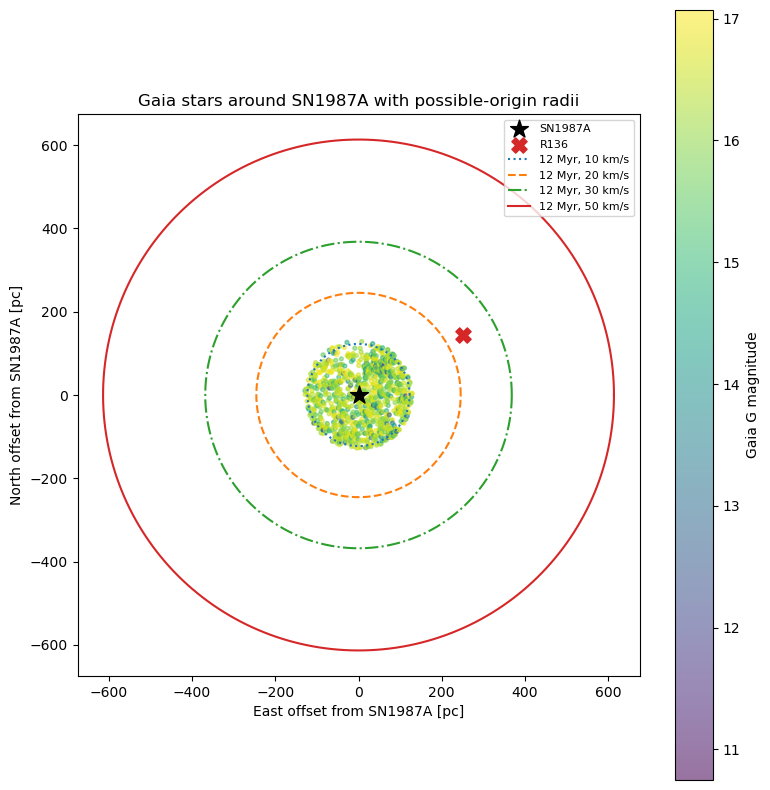

In [4]:
def draw_circle_pc(ax, radius_pc, **kwargs):
    theta = np.linspace(0, 2*np.pi, 500)
    ax.plot(radius_pc*np.cos(theta), radius_pc*np.sin(theta), **kwargs)

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(
    df["x_pc"], df["y_pc"],
    c=df["phot_g_mean_mag"],
    s=8, alpha=0.55
)

ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")
ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:red", label="R136")

# Physically motivated travel radii for 12 Myr
for v, ls in [(10, ":"), (20, "--"), (30, "-."), (50, "-")]:
    r = travel_radius_pc(v, 12)
    draw_circle_pc(ax, r, linestyle=ls, linewidth=1.5, label=f"12 Myr, {v} km/s")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Gaia stars around SN1987A with possible-origin radii")
ax.legend(loc="upper right", fontsize=8)

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Gaia G magnitude")

plt.tight_layout()
plt.savefig(fig_dir / "sn1987a_possible_origin_radii.png", dpi=300)
plt.show()

abover: radius_deg = 0.10. below, zoomed in to the actual queried region

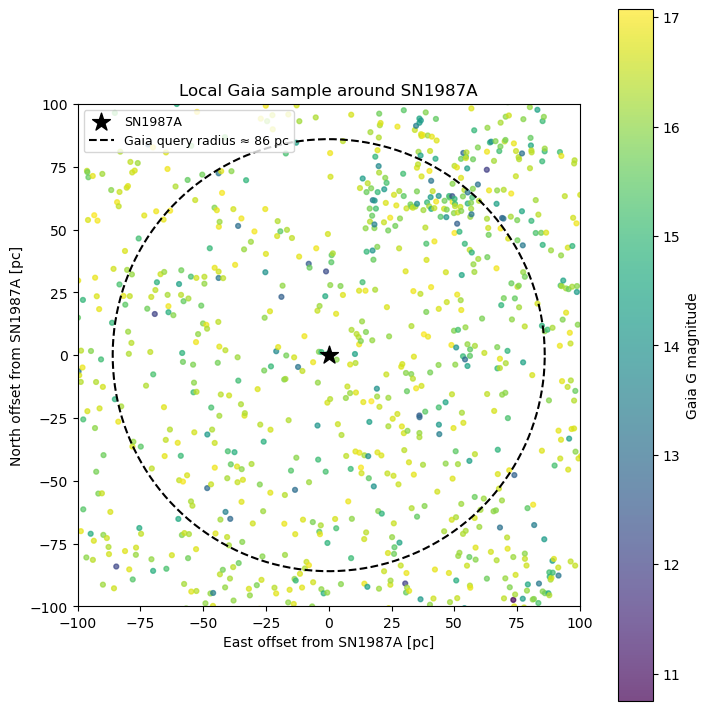

In [5]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

sc = ax.scatter(
    df["x_pc"], df["y_pc"],
    c=df["phot_g_mean_mag"],
    s=12, alpha=0.7
)

ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")

# Show the actual Gaia query radius
query_radius_pc = 86
theta = np.linspace(0, 2*np.pi, 500)
ax.plot(
    query_radius_pc*np.cos(theta),
    query_radius_pc*np.sin(theta),
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Gaia query radius ≈ 86 pc"
)

ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Local Gaia sample around SN1987A")

ax.legend(fontsize=9)
cb = plt.colorbar(sc, ax=ax)
cb.set_label("Gaia G magnitude")

plt.show()

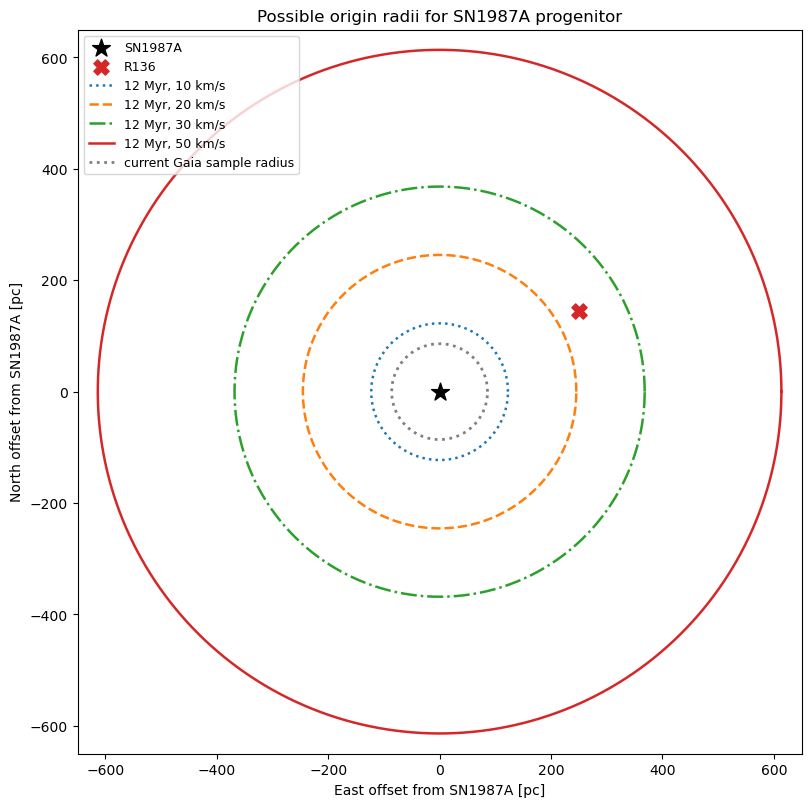

In [6]:
fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)

ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")
ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:red", label="R136")

for v, ls in [(10, ":"), (20, "--"), (30, "-."), (50, "-")]:
    r = travel_radius_pc(v, 12)
    theta = np.linspace(0, 2*np.pi, 500)
    ax.plot(
        r*np.cos(theta),
        r*np.sin(theta),
        linestyle=ls,
        linewidth=1.8,
        label=f"12 Myr, {v} km/s"
    )

# Also show current small Gaia catalogue coverage
query_radius_pc = 86
ax.plot(
    query_radius_pc*np.cos(theta),
    query_radius_pc*np.sin(theta),
    color="grey",
    linestyle=":",
    linewidth=2,
    label="current Gaia sample radius"
)

ax.set_xlim(-650, 650)
ax.set_ylim(-650, 650)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Possible origin radii for SN1987A progenitor")

ax.legend(fontsize=9)
plt.show()

shaded region around the arrow. This uses Monte Carlo sampling of the proper-motion uncertainty and the age range 12 ± 2 Myr. It plots a back-projection arrow and shades the possible origin region.

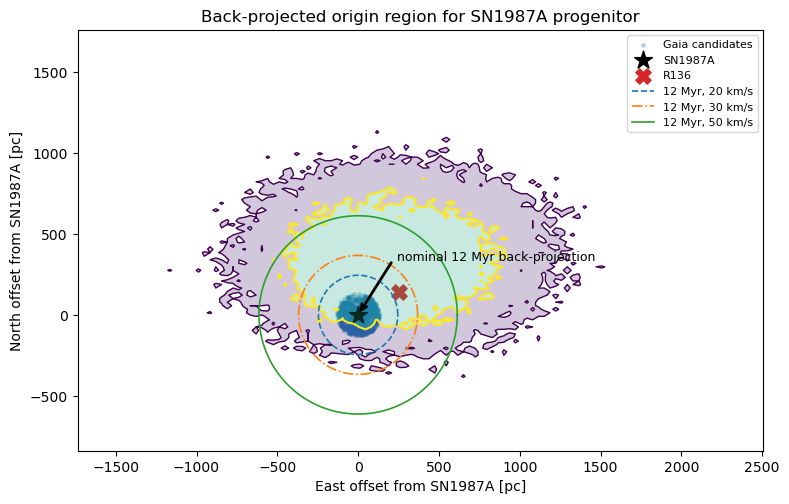

In [7]:
def masyr_to_pc_over_time(mu_masyr, age_myr):
    v_kms = 4.74047 * D_LMC_kpc * mu_masyr
    return v_kms * 1.022712 * age_myr

rng = np.random.default_rng(12345)
n_mc = 50000

# Age range motivated by Panagia et al.
age_samples = rng.normal(12.0, 2.0, n_mc)
age_samples = age_samples[(age_samples > 6) & (age_samples < 20)]

n_mc = len(age_samples)

pmra_87a_s = rng.normal(pmra_87a, pmra_87a_err, n_mc)
pmdec_87a_s = rng.normal(pmdec_87a, pmdec_87a_err, n_mc)

pmra_local_s = rng.normal(pmra_local, pmra_local_err, n_mc)
pmdec_local_s = rng.normal(pmdec_local, pmdec_local_err, n_mc)

pmra_rel_s = pmra_87a_s - pmra_local_s
pmdec_rel_s = pmdec_87a_s - pmdec_local_s

# Back-projected origin = current position - relative displacement
origin_x_s = -masyr_to_pc_over_time(pmra_rel_s, age_samples)
origin_y_s = -masyr_to_pc_over_time(pmdec_rel_s, age_samples)

# Nominal 12 Myr arrow
origin_x_nom = -masyr_to_pc_over_time(pmra_rel_87a, 12.0)
origin_y_nom = -masyr_to_pc_over_time(pmdec_rel_87a, 12.0)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(df["x_pc"], df["y_pc"], s=6, alpha=0.25, label="Gaia candidates")
ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")
ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:red", label="R136")

# 2D density of possible origin points
H, xedges, yedges = np.histogram2d(origin_x_s, origin_y_s, bins=120)
xcent = 0.5 * (xedges[:-1] + xedges[1:])
ycent = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(xcent, ycent)

# Highest-density levels for approximate 68% and 95% regions
vals = np.sort(H.ravel())[::-1]
cdf = np.cumsum(vals) / np.sum(vals)

level68 = vals[np.searchsorted(cdf, 0.68)]
level95 = vals[np.searchsorted(cdf, 0.95)]

ax.contourf(
    X, Y, H.T,
    levels=[level95, level68, H.max()],
    alpha=0.25
)

ax.contour(
    X, Y, H.T,
    levels=[level95, level68],
    linewidths=[1.0, 1.5]
)

ax.annotate(
    "",
    xy=(0, 0),                         # current SN1987A position
    xytext=(origin_x_nom, origin_y_nom),# possible birth/origin point
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.text(origin_x_nom, origin_y_nom, " nominal 12 Myr back-projection", fontsize=9)

# Add 12 Myr travel-radius references
for v, ls in [(20, "--"), (30, "-."), (50, "-")]:
    draw_circle_pc(ax, travel_radius_pc(v, 12), linestyle=ls, linewidth=1.2, label=f"12 Myr, {v} km/s")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Back-projected origin region for SN1987A progenitor")
ax.legend(loc="best", fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / "sn1987a_backprojection_shaded_region.png", dpi=300)
plt.show()

Monte Carlo back-projection of the possible SN 1987A progenitor origin. The arrow shows the nominal 12 Myr traceback using the residual proper motion of SN 1987A after subtracting the local LMC motion estimated from nearby Gaia stars. The blue shaded region shows the uncertainty envelope obtained by sampling the SN 1987A proper-motion errors, the uncertainty in the local Gaia median proper motion, and an assumed progenitor age of 12 ± 2 Myr. The shaded region should be interpreted as a possible-origin region under these assumptions, not as a detected stellar overdensity.

If the arrow is short or the shaded region is huge, that is not a failure. It means the measured proper motion of SN 1987A is very close to the local LMC motion, so the residual motion is weak and uncertain.

The white star at the centre is the current position of SN 1987A. The red cross is R136. The dashed/solid circles show how far a star could travel in 12 Myr if it had a transverse velocity of 20, 30, or 50 km/s. The white arrow is the nominal back-projection of the SN 1987A progenitor over 12 Myr, after subtracting the local LMC proper motion. The coloured shaded/contour region is the Monte Carlo uncertainty region for that back-projected origin.

Using the current residual proper motion estimate, the nominal 12 Myr traceback points roughly northeast of SN 1987A, in the general direction of R136, but the uncertainty region is very broad.”

More specifically, the arrow points to a location somewhat north-east of SN 1987A, and R136 lies in roughly the same quadrant. That is mildly interesting. It means the nominal residual motion is not pointing in a completely unrelated direction. However, the shaded uncertainty region is so large that this plot does not provide a strong origin constraint.

The most important thing to say is that the shaded region overlaps a very large area, including the SN 1987A position itself and regions far beyond R136. This means that, with the current assumptions, the traceback is dominated by uncertainty. We cannot claim “the progenitor came from here.

This figure shows a Monte Carlo back-projection of the possible SN 1987A progenitor origin. The arrow gives the nominal 12 Myr traceback direction after subtracting the local LMC proper motion. The coloured contours show the uncertainty envelope obtained by sampling the proper-motion uncertainties and the assumed 12 ± 2 Myr age range. The result suggests a nominal motion toward the north-east, roughly in the direction of R136, but the uncertainty region is broad. Therefore, this plot does not identify a unique birth site; rather, it shows that proper motion alone currently gives only a weak constraint on the progenitor origin.

The nominal direction is northeast.

R136 lies near the nominal direction, but this is not strong evidence of an R136 origin.

The 20, 30, and 50 km/s circles show that R136 is reachable within 12 Myr at a modest velocity of around 20–30 km/s.

The uncertainty region extends much farther than the physically motivated 12 Myr / 50 km/s travel circle in some directions.

C:\Users\bukow\AppData\Local\Temp\ipykernel_23956\3690741785.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


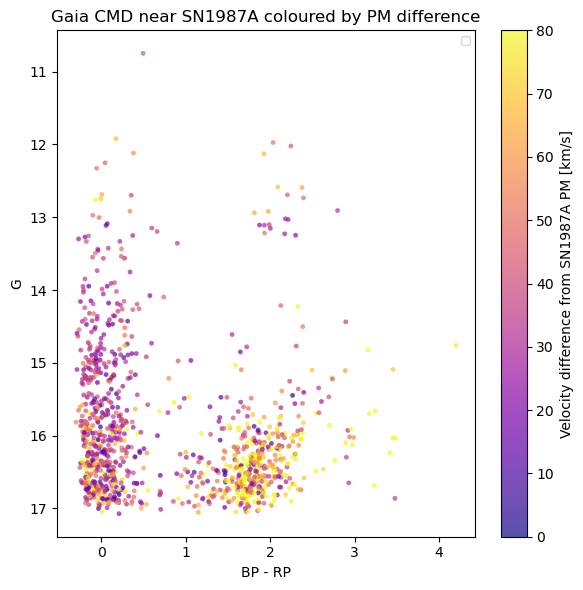

Candidate stars shown: 172


In [8]:
# Plot 1: Gaia CMD coloured by velocity difference from SN1987A

fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    c=df["dv_to_sn87a_kms"],
    vmin=0,
    vmax=80,
    cmap="plasma",
    s=12,
    alpha=0.7,
    edgecolors="none"
)

candidate = df[
    (df["sep_87a_pc"] < 100) &
    (df["dv_to_sn87a_kms"] < 30)
    ].copy()

# the block below circles the ones within 100 pc and with a proper motion difference of less than 30 km/s

# ax.scatter(
#     candidate["bp_rp"],
#     candidate["phot_g_mean_mag"],
#     facecolors="none",
#     edgecolors="black",
#     s=55,
#     linewidths=1.0,
#     label="within 100 pc and 30 km/s"
# )

ax.invert_yaxis()
ax.set_xlabel("BP - RP")
ax.set_ylabel("G")
ax.set_title("Gaia CMD near SN1987A coloured by PM difference")
ax.legend(fontsize=8)

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Velocity difference from SN1987A PM [km/s]")

plt.tight_layout()
plt.savefig(fig_dir / "cmd_sn1987a_candidates_coloured_by_pm.png", dpi=300)
plt.show()

print("Candidate stars shown:", len(candidate))


x-axis: BP - RP colour
y-axis: Gaia G magnitude

The CMD lets me check whether the Gaia stars near SN 1987A include a young stellar population, especially blue massive stars that could plausibly be coeval with the progenitor.

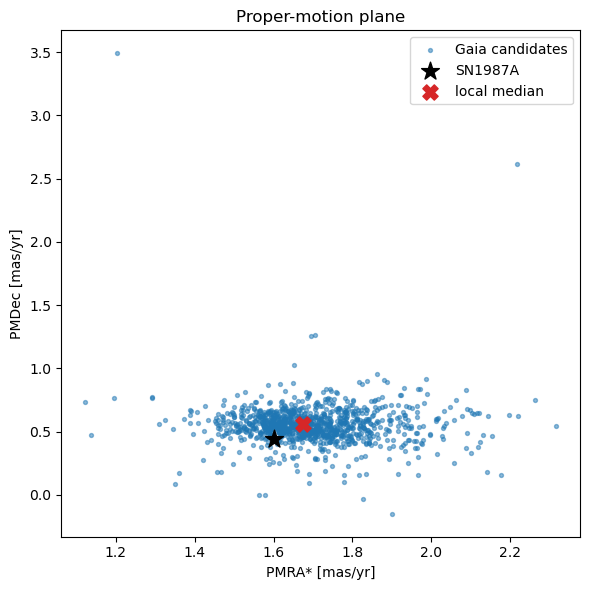

In [9]:


# Plot 2: proper-motion plane
plt.figure(figsize=(6, 6))
plt.scatter(df["pmra"], df["pmdec"], s=8, alpha=0.5, label="Gaia candidates")
plt.scatter(pmra_87a, pmdec_87a, marker="*", s=180, color="black", label="SN1987A")
plt.scatter(pmra_local, pmdec_local, marker="X", s=120, color="tab:red", label="local median")
plt.xlabel("PMRA* [mas/yr]")
plt.ylabel("PMDec [mas/yr]")
plt.title("Proper-motion plane")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "proper_motion_plane.png", dpi=300)
plt.show()

x-axis: PMRA*  [mas/yr]
y-axis: PMDec  [mas/yr]

The proper-motion plane shows whether SN 1987A has a motion distinct from, or consistent with, the local LMC stellar field.

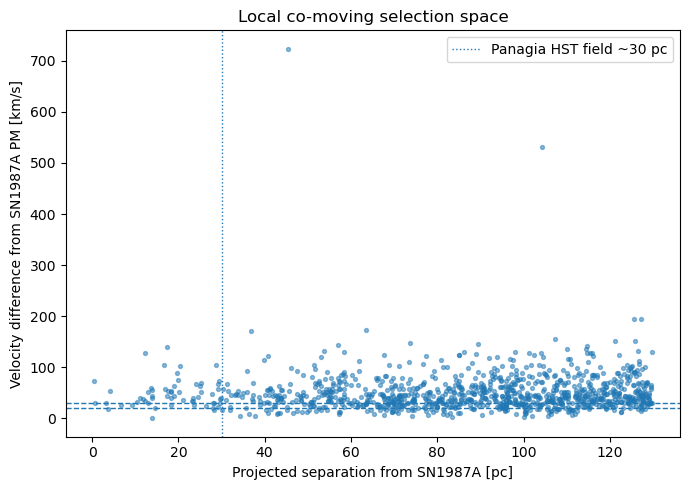

In [10]:



# Plot 3: projected separation vs absolute velocity difference
plt.figure(figsize=(7, 5))
plt.scatter(df["sep_87a_pc"], df["dv_to_sn87a_kms"], s=8, alpha=0.5)
plt.axhline(20, linestyle="--", linewidth=1)
plt.axhline(30, linestyle="--", linewidth=1)
plt.axvline(30, linestyle=":", linewidth=1, label="Panagia HST field ~30 pc")
plt.xlabel("Projected separation from SN1987A [pc]")
plt.ylabel("Velocity difference from SN1987A PM [km/s]")
plt.title("Local co-moving selection space")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "separation_vs_velocity_difference.png", dpi=300)
plt.show()


x-axis: projected distance from SN1987A [pc]
y-axis: velocity difference from SN1987A proper motion [km/s]

This plot helps identify stars that are both near SN 1987A and moving similarly, which are the most plausible local environmental candidates.

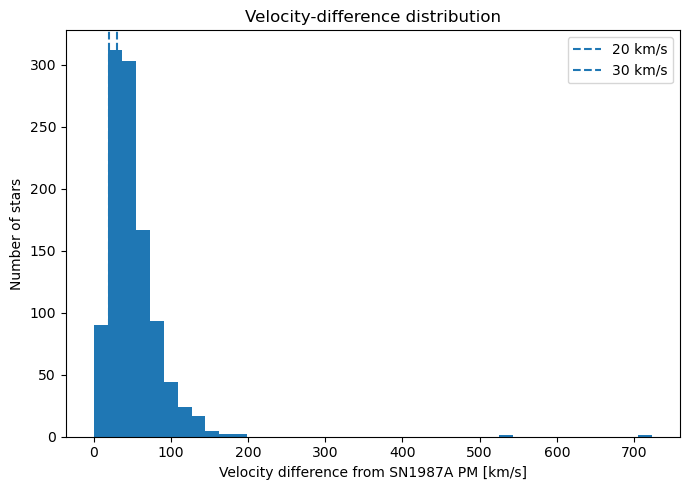

In [11]:


# Plot 4: velocity-difference histogram
plt.figure(figsize=(7, 5))
plt.hist(df["dv_to_sn87a_kms"].dropna(), bins=40)
plt.axvline(20, linestyle="--", label="20 km/s")
plt.axvline(30, linestyle="--", label="30 km/s")
plt.xlabel("Velocity difference from SN1987A PM [km/s]")
plt.ylabel("Number of stars")
plt.title("Velocity-difference distribution")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "velocity_difference_histogram.png", dpi=300)
plt.show()



x-axis: velocity difference from SN1987A or from the local residual motion [km/s]
y-axis: number of stars

The velocity distribution tells me how unusual a given velocity difference is, and helps justify the velocity cut used to select co-moving candidates.

In [12]:
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord

# Distance to LMC
D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000

# Coordinates
sn87a_coord = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")
r136_coord = SkyCoord(ra=84.6767920*u.deg, dec=-69.1006110*u.deg, frame="icrs")

# Offset of R136 relative to SN1987A
sep_pc = sn87a_coord.separation(r136_coord).rad * D_LMC_pc
pa = sn87a_coord.position_angle(r136_coord).rad

r136_x_pc = sep_pc * np.sin(pa)   # east offset
r136_y_pc = sep_pc * np.cos(pa)   # north offset

print("R136 offset from SN1987A:")
print("x/east [pc]:", r136_x_pc)
print("y/north [pc]:", r136_y_pc)
print("projected separation [pc]:", np.sqrt(r136_x_pc**2 + r136_y_pc**2))

R136 offset from SN1987A:
x/east [pc]: 250.1352097371921
y/north [pc]: 144.74111444921246
projected separation [pc]: 288.99414070577467


check whether the selection actually contains stars:

In [13]:
print("Total df rows:", len(df))

fast = df[
    (df["dv_to_sn87a_kms"] > 50) &
    (df["ruwe"] < 1.4) &
    (df["pmra_error"] < 0.2) &
    (df["pmdec_error"] < 0.2)
    ].copy()

print("Fast cleaned rows:", len(fast))
print(df[["dv_to_sn87a_kms", "ruwe", "pmra_error", "pmdec_error"]].describe())

Total df rows: 1061
Fast cleaned rows: 422
       dv_to_sn87a_kms         ruwe   pmra_error  pmdec_error
count      1061.000000  1061.000000  1061.000000  1061.000000
mean         50.722111     1.009936     0.051141     0.048259
std          38.434668     0.078828     0.016074     0.014797
min           0.291809     0.781980     0.013511     0.013203
25%          30.014164     0.963462     0.039502     0.037427
50%          43.155651     1.001007     0.052220     0.049651
75%          63.524051     1.048592     0.063177     0.060322
max         723.316194     1.387878     0.097803     0.084522


x-axis: east offset from SN1987A [pc]
y-axis: north offset from SN1987A [pc]
colour: velocity difference [km/s]

This map shows whether kinematically similar stars are spatially clustered around SN 1987A or distributed like the general LMC field.

Stars above colour scale limit, >150 km/s: 9


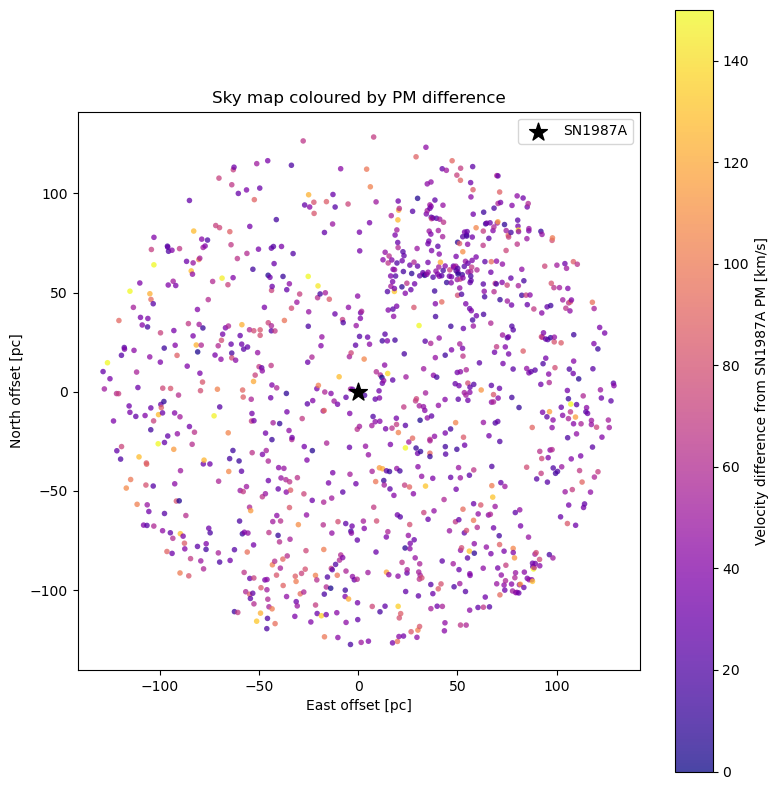

In [14]:
# Plot 5: sky map coloured by velocity difference
# Colour scale clipped so normal stars are not hidden by extreme outliers.

fig, ax = plt.subplots(figsize=(8, 8))

sc = ax.scatter(
    df["x_pc"],
    df["y_pc"],
    c=df["dv_to_sn87a_kms"],
    vmin=0,
    vmax=150,
    cmap="plasma",
    s=16,
    alpha=0.75,
    edgecolors="none"
)

ax.scatter(0, 0, marker="*", s=180, color="black", label="SN1987A")
#ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:red", label="R136")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("East offset [pc]")
ax.set_ylabel("North offset [pc]")
ax.set_title("Sky map coloured by PM difference")
ax.legend()

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Velocity difference from SN1987A PM [km/s]")

outliers = df[df["dv_to_sn87a_kms"] > 150]
print("Stars above colour scale limit, >150 km/s:", len(outliers))

plt.tight_layout()
plt.savefig(fig_dir / "sky_map_coloured_by_velocity_difference.png", dpi=300)
plt.show()

Stars plotted as arrows: 539


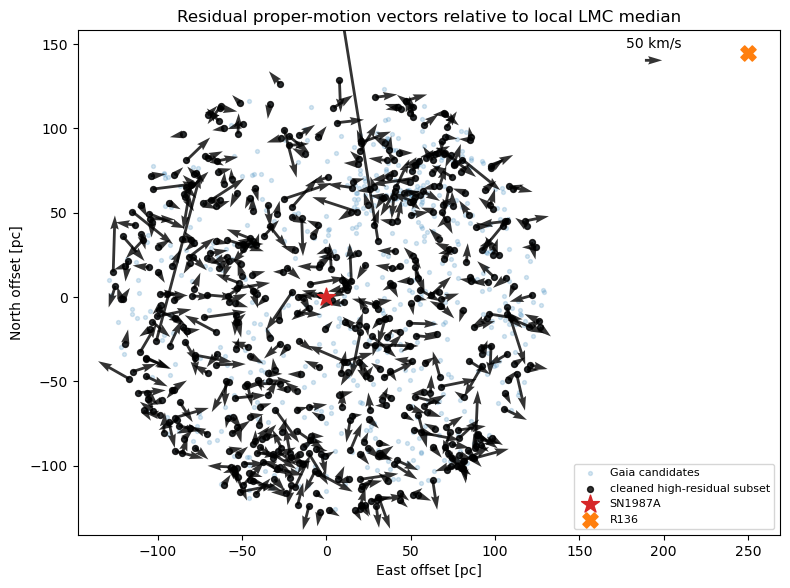

In [15]:
# Plot 6: residual proper-motion vectors on the sky
# Arrows show motion relative to the local LMC median.

arrow_time_myr = 0.2

# Convert residual proper motion into pc travelled over arrow_time_myr
pm_to_pc = 4.74047 * D_LMC_kpc * 1.022712 * arrow_time_myr

# Clean subset for arrows
sub = df[
    (df["ruwe"] < 1.4) &
    (df["pmra_error"] < 0.5) &
    (df["pmdec_error"] < 0.5)
    ].copy()

# For readability, keep only the larger residual motions
sub = sub[sub["dv_to_local_kms"] > 30].copy()

print("Stars plotted as arrows:", len(sub))

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    df["x_pc"],
    df["y_pc"],
    s=8,
    alpha=0.18,
    color="tab:blue",
    label="Gaia candidates"
)

ax.scatter(
    sub["x_pc"],
    sub["y_pc"],
    s=18,
    alpha=0.8,
    color="black",
    label="cleaned high-residual subset"
)

U = (sub["pmra"] - pmra_local) * pm_to_pc
V = (sub["pmdec"] - pmdec_local) * pm_to_pc

q = ax.quiver(
    sub["x_pc"],
    sub["y_pc"],
    U,
    V,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    alpha=0.8,
    color="black"
)

# Quiver scale: 50 km/s over 0.2 Myr
ref_pc = 50 * 1.022712 * arrow_time_myr
ax.quiverkey(
    q,
    X=0.82,
    Y=0.94,
    U=ref_pc,
    label="50 km/s",
    coordinates="axes"
)

ax.scatter(0, 0, marker="*", s=180, color="tab:red", label="SN1987A")
ax.scatter(x_r136_pc, y_r136_pc, marker="X", s=120, color="tab:orange", label="R136")

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("East offset [pc]")
ax.set_ylabel("North offset [pc]")
ax.set_title("Residual proper-motion vectors relative to local LMC median")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(fig_dir / "residual_pm_vectors_cleaned.png", dpi=300)
plt.show()

star proper motion − local LMC proper motion

The residual vector field removes the bulk LMC motion and shows whether there are coherent local motions or individual runaway-like objects.

These plots are meant to separate three things: the stellar population age information from the CMD, the kinematic information from proper motions, and the spatial information from projected positions. I am using them together to see whether the environment around SN 1987A contains a coherent group of stars that could be related to the progenitor, and whether any candidate origin region stands out.

the “just big arrows” version, only plot stars with something like:

a quiver scale: right now the arrows are visually arbitrary; converted the proper motions into physical displacements over a chosen display time, 0.2 Myr:

Stars plotted as arrows: 796


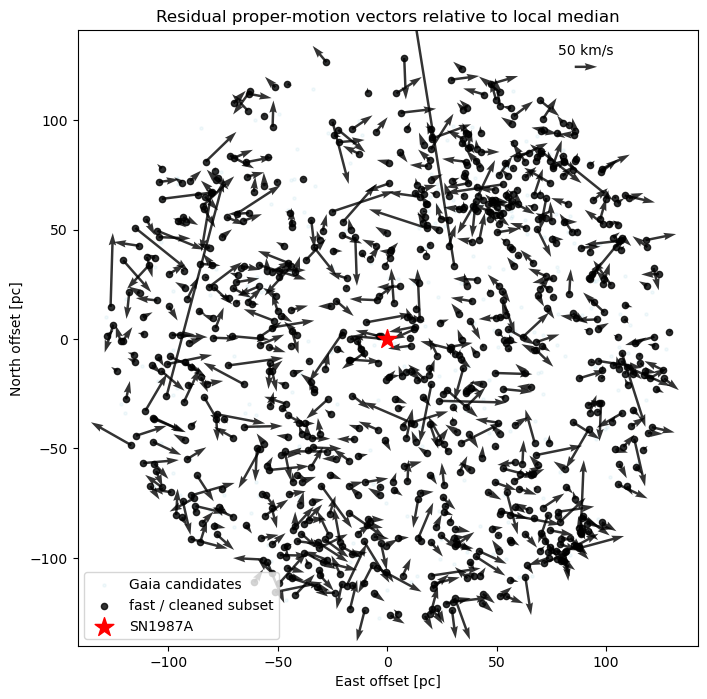

In [16]:
sub = df[
    (df["dv_to_sn87a_kms"] > 30) &
    (df["ruwe"] < 1.4) &
    (df["pmra_error"] < 0.5) &
    (df["pmdec_error"] < 0.5)
    ].copy()

print("Stars plotted as arrows:", len(sub))

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    df["x_pc"],
    df["y_pc"],
    s=5,
    alpha=0.15,
    color="lightblue",
    label="Gaia candidates"
)

ax.scatter(
    sub["x_pc"],
    sub["y_pc"],
    s=20,
    color="black",
    alpha=0.8,
    label="fast / cleaned subset"
)

arrow_time_myr = 0.2

# Converts mas/yr into pc travelled over arrow_time_myr.
# 1 mas/yr at distance D[kpc] = 4.74047 * D km/s.
# 1 km/s = 1.022712 pc/Myr.
pm_to_pc = 4.74047 * D_LMC_kpc * 1.022712 * arrow_time_myr

U = (sub["pmra"] - pmra_local) * pm_to_pc
V = (sub["pmdec"] - pmdec_local) * pm_to_pc

q = ax.quiver(
    sub["x_pc"],
    sub["y_pc"],
    U,
    V,
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.004,
    alpha=0.8,
    color="black"
)

ref_pc = 50 * 1.022712 * arrow_time_myr
ax.quiverkey(
    q,
    X=0.82,
    Y=0.94,
    U=ref_pc,
    label="50 km/s",
    coordinates="axes"
)

ax.scatter(0, 0, marker="*", s=200, color="red", label="SN1987A")

ax.set_xlabel("East offset [pc]")
ax.set_ylabel("North offset [pc]")
ax.set_title("Residual proper-motion vectors relative to local median")
ax.set_aspect("equal", adjustable="box")
ax.legend()

plt.savefig(fig_dir / "residual_pm_vectors_cleaned.png", dpi=300)
plt.show()


## Candidate table

source_id

ra, dec

x_pc, y_pc

sep_87a_pc

phot_g_mean_mag

bp_rp

pmra, pmdec

pmra_error, pmdec_error

ruwe

dv_to_sn87a_kms

dv_local_resid_kms

candidate_class

dv_to_sn87a_kms: direct velocity difference from the Tegkelidis SN1987A proper motion.

dv_local_resid_kms: velocity difference after subtracting the local LMC median motion

### After quality cuts, X stars remain; Y are within 100 pc and within 30 km/s of the SN1987A residual motion.

local CMD is useful but sparse; 
broad CMD is dense but includes many unrelated LMC populations and likely some foreground contamination

For the candidate analysis:

1. CMD of all cleaned local stars.
2. CMD coloured by velocity difference.
3. CMD with candidate stars outlined.


In [17]:
import numpy as np

# LMC distance
D_LMC_kpc = 49.59

# Convert proper motion difference in mas/yr to km/s
masyr_to_kms = 4.74047 * D_LMC_kpc

# If these are not already defined, use the median PM of your current sample
pmra_local = df["pmra"].median()
pmdec_local = df["pmdec"].median()

print("Local median PMRA*:", pmra_local)
print("Local median PMDec:", pmdec_local)

# Peculiar / residual velocity relative to the local LMC median motion
df["dv_local_resid_kms"] = masyr_to_kms * np.sqrt(
    (df["pmra"] - pmra_local)**2 +
    (df["pmdec"] - pmdec_local)**2
)

print(df["dv_local_resid_kms"].describe())

Local median PMRA*: 1.6840932068779009
Local median PMDec: 0.5510663456112924
count    1061.000000
mean       38.548196
std        36.464745
min         0.529020
25%        18.718998
50%        31.417369
75%        48.817054
max       700.349845
Name: dv_local_resid_kms, dtype: float64


C:\Users\bukow\AppData\Local\Temp\ipykernel_23956\995241843.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["dv_local_resid_kms"] = masyr_to_kms * np.sqrt(


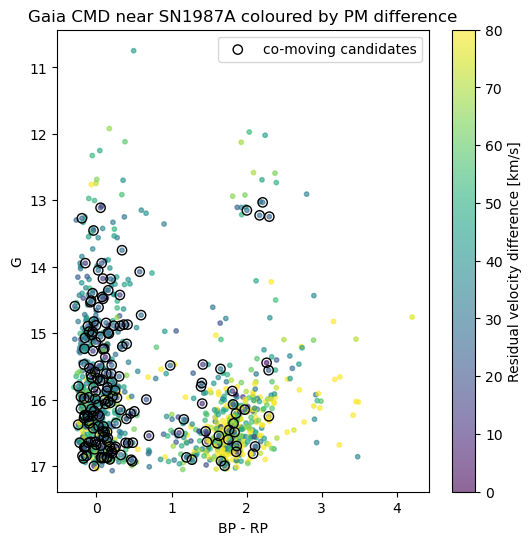

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    df["bp_rp"],
    df["phot_g_mean_mag"],
    c=df["dv_to_sn87a_kms"],
    vmin=0,
    vmax=80,
    s=10,
    alpha=0.6
)

cand = df[
    (df["sep_87a_pc"] < 100) &
    (df["dv_to_sn87a_kms"] < 30)
    ]

ax.scatter(
    cand["bp_rp"],
    cand["phot_g_mean_mag"],
    facecolors="none",
    edgecolors="black",
    s=45,
    label="co-moving candidates"
)

ax.invert_yaxis()
ax.set_xlabel("BP - RP")
ax.set_ylabel("G")
ax.set_title("Gaia CMD near SN1987A coloured by PM difference")
ax.legend()

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Residual velocity difference [km/s]")

low values are stars moving similarly to the local LMC population; high values are possible runaways, foreground contaminants, bad Gaia solutions, or genuinely peculiar stars.

velocity difference from SN1987A specifically:

**one** extra diagnostic plot: only stars with dv_to_sn87a_kms < 30, over the sky map

Total stars in local Gaia sample: 1061
Loose candidates: within 100 pc and <20 km/s: 65
Strict candidates: within 30 pc and <20 km/s: 3


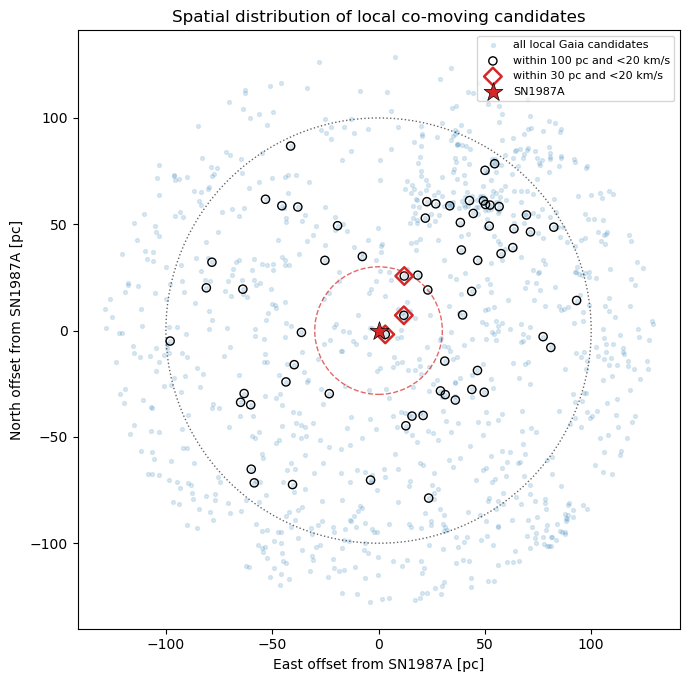

In [19]:
# Simple substructure check: loose and strict local co-moving candidates

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord, SkyOffsetFrame

# ------------------------------------------------------------
# Load df if needed
# ------------------------------------------------------------

output_dir = Path("output_files")
fig_dir = Path("figures")
fig_dir.mkdir(exist_ok=True)

if "df" not in globals():
    preferred_file = output_dir / "SN1987A_cands_with_selection_flags.csv"
    fallback_file = output_dir / "SN1987A_cands.csv"

    if preferred_file.exists():
        df = pd.read_csv(preferred_file, low_memory=False)
        print("Loaded:", preferred_file)
    elif fallback_file.exists():
        df = pd.read_csv(fallback_file, low_memory=False)
        print("Loaded:", fallback_file)
    else:
        raise FileNotFoundError(
            "Could not find SN1987A_cands_with_selection_flags.csv or SN1987A_cands.csv"
        )

df.columns = df.columns.str.strip()

# ------------------------------------------------------------
# Add derived columns if missing
# ------------------------------------------------------------

D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000
masyr_to_kms = 4.74047 * D_LMC_kpc

sn87a = SkyCoord("05h35m27.9884s", "-69d16m11.1134s", frame="icrs")

pmra_87a = 1.60
pmdec_87a = 0.44

if not {"x_pc", "y_pc", "sep_87a_pc"}.issubset(df.columns):
    coords = SkyCoord(
        ra=df["ra"].values * u.deg,
        dec=df["dec"].values * u.deg,
        frame="icrs"
    )

    frame_87a = SkyOffsetFrame(origin=sn87a)
    offsets = coords.transform_to(frame_87a)

    df["x_pc"] = offsets.lon.to_value(u.rad) * D_LMC_pc
    df["y_pc"] = offsets.lat.to_value(u.rad) * D_LMC_pc
    df["sep_87a_pc"] = np.sqrt(df["x_pc"]**2 + df["y_pc"]**2)

if "dv_to_sn87a_kms" not in df.columns:
    df["dpm_abs_87a_masyr"] = np.hypot(
        df["pmra"] - pmra_87a,
        df["pmdec"] - pmdec_87a
    )
    df["dv_to_sn87a_kms"] = masyr_to_kms * df["dpm_abs_87a_masyr"]

# ------------------------------------------------------------
# Define candidate classes
# ------------------------------------------------------------

loose = df[
    (df["sep_87a_pc"] < 100) &
    (df["dv_to_sn87a_kms"] < 20)
    ].copy()

strict = df[
    (df["sep_87a_pc"] < 30) &
    (df["dv_to_sn87a_kms"] < 20)
    ].copy()

print("Total stars in local Gaia sample:", len(df))
print("Loose candidates: within 100 pc and <20 km/s:", len(loose))
print("Strict candidates: within 30 pc and <20 km/s:", len(strict))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    df["x_pc"],
    df["y_pc"],
    s=8,
    alpha=0.15,
    color="tab:blue",
    label="all local Gaia candidates"
)

ax.scatter(
    loose["x_pc"],
    loose["y_pc"],
    s=35,
    facecolors="none",
    edgecolors="black",
    linewidths=1.0,
    label="within 100 pc and <20 km/s"
)

ax.scatter(
    strict["x_pc"],
    strict["y_pc"],
    s=80,
    marker="D",
    facecolors="none",
    edgecolors="tab:red",
    linewidths=1.8,
    label="within 30 pc and <20 km/s"
)

ax.scatter(
    0,
    0,
    marker="*",
    s=200,
    color="tab:red",
    edgecolor="black",
    linewidth=0.5,
    label="SN1987A"
)

# Optional guide circles
circle_30 = plt.Circle(
    (0, 0),
    30,
    color="tab:red",
    fill=False,
    linestyle="--",
    linewidth=1.0,
    alpha=0.7
)
circle_100 = plt.Circle(
    (0, 0),
    100,
    color="black",
    fill=False,
    linestyle=":",
    linewidth=1.0,
    alpha=0.6
)

ax.add_patch(circle_30)
ax.add_patch(circle_100)

ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Spatial distribution of local co-moving candidates")
ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.savefig(fig_dir / "local_comoving_candidates_sky_distribution_strict.png", dpi=300)
plt.show()

## Inspect the three strict local candidates

In [20]:
# inspecting the strict local co-moving candidates

from pathlib import Path
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord

output_dir = Path("output_files")
output_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# getting the cleaned local Gaia dataframe
# ------------------------------------------------------------

if "df" in globals():
    base_df = df.copy()
    print("Using dataframe: df")

elif "df_substructure" in globals():
    base_df = base_df.copy()
    print("Using dataframe: base_df")

else:
    preferred_file = output_dir / "SN1987A_cands_with_selection_flags.csv"
    fallback_file = output_dir / "SN1987A_cands.csv"

    if preferred_file.exists():
        base_df = pd.read_csv(preferred_file, low_memory=False)
        print("Loaded:", preferred_file)

    elif fallback_file.exists():
        base_df = pd.read_csv(fallback_file, low_memory=False)
        print("Loaded:", fallback_file)

    else:
        raise FileNotFoundError(
            "Could not find SN1987A_cands_with_selection_flags.csv "
            "or SN1987A_cands.csv in output_files/"
        )

base_df.columns = base_df.columns.str.strip()

# ------------------------------------------------------------
# recalculating the required quantities consistently
# ------------------------------------------------------------

D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000
masyr_to_kms = 4.74047 * D_LMC_kpc

pmra_87a = 1.60
pmdec_87a = 0.44

sn87a_coord = SkyCoord(
    "05h35m27.9884s",
    "-69d16m11.1134s",
    frame="icrs"
)

star_coords = SkyCoord(
    ra=base_df["ra"].to_numpy() * u.deg,
    dec=base_df["dec"].to_numpy() * u.deg,
    frame="icrs"
)

east_offset, north_offset = sn87a_coord.spherical_offsets_to(star_coords)

base_df["x_pc"] = east_offset.to_value(u.rad) * D_LMC_pc
base_df["y_pc"] = north_offset.to_value(u.rad) * D_LMC_pc

base_df["sep_87a_pc"] = (
        sn87a_coord.separation(star_coords).to_value(u.rad)
        * D_LMC_pc
)

base_df["dpm_abs_87a_masyr"] = np.hypot(
    base_df["pmra"] - pmra_87a,
    base_df["pmdec"] - pmdec_87a
)

base_df["dv_to_sn87a_kms"] = (
        masyr_to_kms * base_df["dpm_abs_87a_masyr"]
)

# Calculate BP-RP if needed
if "bp_rp" not in base_df.columns:
    base_df["bp_rp"] = (
            base_df["phot_bp_mean_mag"]
            - base_df["phot_rp_mean_mag"]
    )

# ------------------------------------------------------------
# recreating the strict selection
# ------------------------------------------------------------

strict_inspect = base_df[
    (base_df["sep_87a_pc"] < 30) &
    (base_df["dv_to_sn87a_kms"] < 20)
    ].copy()

strict_inspect = strict_inspect.sort_values(
    by=["sep_87a_pc", "dv_to_sn87a_kms"]
).reset_index(drop=True)

strict_inspect["candidate"] = [
    f"C{i + 1}" for i in range(len(strict_inspect))
]

print("Number of strict candidates:", len(strict_inspect))

# ------------------------------------------------------------
# comparing with the local LMC median
# ------------------------------------------------------------

local_reference = base_df[
    base_df["sep_87a_pc"] < 100
    ].copy()

pmra_local = np.nanmedian(local_reference["pmra"])
pmdec_local = np.nanmedian(local_reference["pmdec"])

strict_inspect["dv_to_local_kms"] = masyr_to_kms * np.hypot(
    strict_inspect["pmra"] - pmra_local,
    strict_inspect["pmdec"] - pmdec_local
)

# proper-motion difference significance, including the published SN1987A proper-motion uncertainties
sigma_ra = np.sqrt(
    strict_inspect["pmra_error"]**2 + 0.15**2
)

sigma_dec = np.sqrt(
    strict_inspect["pmdec_error"]**2 + 0.09**2
)

strict_inspect["pm_offset_significance"] = np.sqrt(
    (
            (strict_inspect["pmra"] - pmra_87a)
            / sigma_ra
    )**2
    +
    (
            (strict_inspect["pmdec"] - pmdec_87a)
            / sigma_dec
    )**2
)

# making Gaia source IDs display normally
if "source_id" in strict_inspect.columns:
    strict_inspect["source_id_text"] = (
        strict_inspect["source_id"]
        .astype("Int64")
        .astype(str)
    )

# ------------------------------------------------------------
# displaying the useful information
# ------------------------------------------------------------

inspection_columns = [
    "candidate",
    "source_id_text",
    "ra",
    "dec",
    "phot_g_mean_mag",
    "bp_rp",
    "sep_87a_pc",
    "dv_to_sn87a_kms",
    "dv_to_local_kms",
    "pmra",
    "pmdec",
    "pmra_error",
    "pmdec_error",
    "ruwe",
    "pm_offset_significance"
]

inspection_columns = [
    column for column in inspection_columns
    if column in strict_inspect.columns
]

inspection_table = strict_inspect[inspection_columns].copy()

numeric_columns = inspection_table.select_dtypes(
    include=[np.number]
).columns

inspection_table[numeric_columns] = (
    inspection_table[numeric_columns].round(3)
)

display(inspection_table)

print()
print("Local median PMRA*:", round(pmra_local, 3), "mas/yr")
print("Local median PMDec:", round(pmdec_local, 3), "mas/yr")

# ------------------------------------------------------------
# automatically identifying the most notable candidates
# ------------------------------------------------------------

if len(strict_inspect) > 0:
    nearest = strict_inspect.loc[
        strict_inspect["sep_87a_pc"].idxmin()
    ]

    closest_pm = strict_inspect.loc[
        strict_inspect["dv_to_sn87a_kms"].idxmin()
    ]

    bluest = strict_inspect.loc[
        strict_inspect["bp_rp"].idxmin()
    ]

    print()
    print(
        "Nearest candidate:",
        nearest["candidate"],
        "- separation =",
        round(nearest["sep_87a_pc"], 2),
        "pc"
    )

    print(
        "Closest proper-motion match:",
        closest_pm["candidate"],
        "- Δv from SN1987A =",
        round(closest_pm["dv_to_sn87a_kms"], 2),
        "km/s"
    )

    print(
        "Bluest candidate:",
        bluest["candidate"],
        "- BP-RP =",
        round(bluest["bp_rp"], 2)
    )

# ------------------------------------------------------------
# saving the result
# ------------------------------------------------------------

strict_inspect.to_csv(
    output_dir / "SN1987A_strict_candidates.csv",
    index=False
)

print()
print(
    "Saved:",
    output_dir / "SN1987A_strict_candidates.csv"
)

Using dataframe: df
Number of strict candidates: 3


,candidate,source_id_text,ra,dec,phot_g_mean_mag,bp_rp,sep_87a_pc,dv_to_sn87a_kms,dv_to_local_kms,pmra,pmdec,pmra_error,pmdec_error,ruwe,pm_offset_significance
0,C1,4657668011359871104,83.877,-69.272,15.959,-0.206,3.629,17.849,44.336,1.524,0.443,0.051,0.044,0.986,0.479
1,C2,4657668045719604608,83.905,-69.261,16.359,-0.097,13.913,0.292,32.432,1.600,0.441,0.060,0.053,1.050,0.012
2,C3,4657668458014235392,83.906,-69.240,16.720,-0.153,28.370,15.715,17.491,1.646,0.488,0.073,0.060,0.914,0.526



Local median PMRA*: 1.674 mas/yr
Local median PMDec: 0.557 mas/yr

Nearest candidate: C1 - separation = 3.63 pc
Closest proper-motion match: C2 - Δv from SN1987A = 0.29 km/s
Bluest candidate: C1 - BP-RP = -0.21

Saved: output_files\SN1987A_strict_candidates.csv


making a clear zoomed image of the plotted stars:

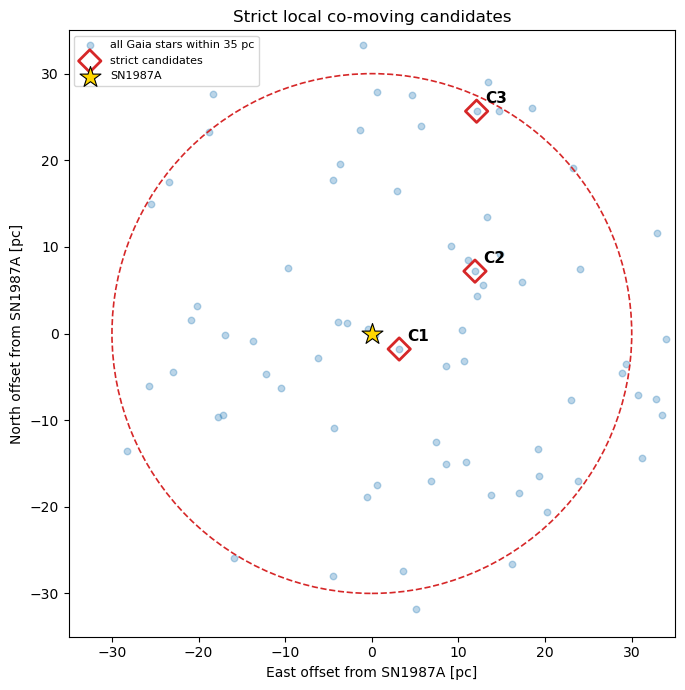

In [21]:
# Zoomed spatial plot of the strict candidates

import matplotlib.pyplot as plt

local_35pc = base_df[
    base_df["sep_87a_pc"] < 35
    ].copy()

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    local_35pc["x_pc"],
    local_35pc["y_pc"],
    s=22,
    alpha=0.30,
    color="tab:blue",
    label="all Gaia stars within 35 pc"
)

ax.scatter(
    strict_inspect["x_pc"],
    strict_inspect["y_pc"],
    s=130,
    marker="D",
    facecolors="none",
    edgecolors="tab:red",
    linewidths=2,
    label="strict candidates"
)

for _, star in strict_inspect.iterrows():
    ax.annotate(
        star["candidate"],
        xy=(star["x_pc"], star["y_pc"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

ax.scatter(
    0,
    0,
    marker="*",
    s=250,
    color="gold",
    edgecolor="black",
    linewidth=0.8,
    label="SN1987A"
)

circle_30 = plt.Circle(
    (0, 0),
    30,
    fill=False,
    linestyle="--",
    color="tab:red",
    linewidth=1.2
)

ax.add_patch(circle_30)

ax.set_xlim(-35, 35)
ax.set_ylim(-35, 35)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("East offset from SN1987A [pc]")
ax.set_ylabel("North offset from SN1987A [pc]")
ax.set_title("Strict local co-moving candidates")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    fig_dir / "strict_candidates_spatial_zoom.png",
    dpi=300
)
plt.show()

G = the apparent brightness. A lower number means a brighter star.

BP-RP = roughly how blue or red the star is. Values near zero are relatively blue; larger positive values are redder.

Separation = how far the star lies from SN1987A in projected distance.

\(\Delta v_{87A}\) is the transverse-velocity difference from the adopted SN1987A proper motion.

\(\Delta v_{\mathrm{local}}\) = how unusual the star is relative to the nearby LMC field. This is important because SN1987A itself moves similarly to the local LMC population.

RUWE checks the quality of Gaia’s astrometric solution. Values below approximately 1.4 are generally preferable.

pm_offset_significance indicates how strongly the star’s proper motion differs from the SN1987A value after including measurement uncertainties. A smaller value means the motions are more statistically compatible.

## Characterisation of the three strict candidates

Loaded: output_files\SN1987A_cands_with_selection_flags.csv

DIRECT ANSWERS
--------------
Nearest candidate: C1 (3.63 pc)
Smallest velocity difference from SN1987A: C2 (0.29 km/s)
Bluest candidate: C1 (BP-RP = -0.21)

Gaia quality:
  C1: passes adopted quality cuts = True; RUWE = 0.986; PM errors = (0.051, 0.044) mas/yr
  C2: passes adopted quality cuts = True; RUWE = 1.050; PM errors = (0.060, 0.053) mas/yr
  C3: passes adopted quality cuts = True; RUWE = 0.914; PM errors = (0.073, 0.060) mas/yr

Comparison with local median:
  C1: Δv87A = 17.85 km/s, Δvlocal = 44.34 km/s; closer to SN1987A PM
  C2: Δv87A = 0.29 km/s, Δvlocal = 32.43 km/s; closer to SN1987A PM
  C3: Δv87A = 15.71 km/s, Δvlocal = 17.49 km/s; similarly close to both

Local median PM: (1.674, 0.557) mas/yr


,candidate,source_id_text,phot_g_mean_mag,bp_rp,sep_87a_pc,dv_to_sn87a_kms,dv_to_local_kms,pmra_error,pmdec_error,ruwe,pm_offset_significance,passes_adopted_quality,motion_comparison
0,C1,4657668011359871104,15.959,-0.206,3.629,17.849,44.336,0.051,0.044,0.986,0.479,True,closer to SN1987A PM
1,C2,4657668045719604608,16.359,-0.097,13.913,0.292,32.432,0.060,0.053,1.050,0.012,True,closer to SN1987A PM
2,C3,4657668458014235392,16.720,-0.153,28.370,15.715,17.491,0.073,0.060,0.914,0.526,True,similarly close to both



REPORT PARAGRAPH
----------------
Three Gaia DR3 sources satisfy the strict selection of a projected separation below 30 pc and a transverse-velocity difference below 20 km s$^{-1}$ from the adopted SN 1987A proper motion. Candidate C1 is the nearest source, at a projected separation of 3.63 pc. Candidate C2 provides the closest proper-motion match, with $\Delta v_{87A}=0.29$ km s$^{-1}$. Candidate C1 is the bluest of the three, with $G_{BP}-G_{RP}=-0.21$. Its colour alone is not sufficient to establish membership in a young stellar population. All three candidates pass the adopted Gaia DR3 astrometric-quality criteria. The candidates C3 also lie within 30 km s$^{-1}$ of the local median motion. Their similarity to SN 1987A is therefore not unique.


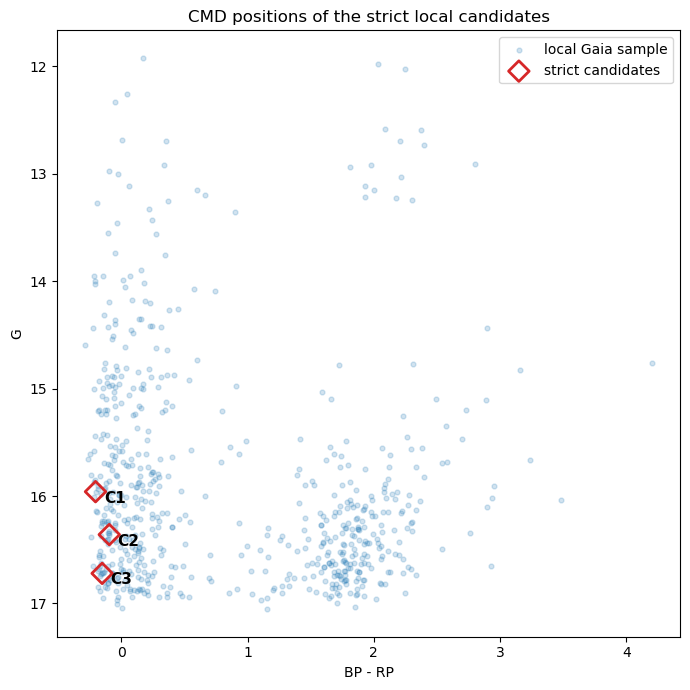


Saved:
output_files\SN1987A_strict_candidates_characterised.csv
output_files\SN1987A_strict_candidate_table.tex
output_files\SN1987A_strict_candidate_interpretation.tex
figures\strict_candidates_cmd.png


In [22]:
# Characterisation of the three strict local co-moving candidates

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord

output_dir = Path("output_files")
fig_dir = Path("figures")

output_dir.mkdir(exist_ok=True)
fig_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 1. Load the cleaned local Gaia catalogue
# ------------------------------------------------------------

preferred_file = output_dir / "SN1987A_cands_with_selection_flags.csv"
fallback_file = output_dir / "SN1987A_cands.csv"

if preferred_file.exists():
    base_df = pd.read_csv(preferred_file, low_memory=False)
    print("Loaded:", preferred_file)

elif fallback_file.exists():
    base_df = pd.read_csv(fallback_file, low_memory=False)
    print("Loaded:", fallback_file)

else:
    raise FileNotFoundError(
        "Could not find SN1987A_cands_with_selection_flags.csv "
        "or SN1987A_cands.csv in output_files/"
    )

base_df.columns = base_df.columns.str.strip()

# ------------------------------------------------------------
# 2. Recalculate positions and proper-motion differences
# ------------------------------------------------------------

D_LMC_kpc = 49.59
D_LMC_pc = D_LMC_kpc * 1000
masyr_to_kms = 4.74047 * D_LMC_kpc

pmra_87a = 1.60
pmdec_87a = 0.44

sn87a_coord = SkyCoord(
    "05h35m27.9884s",
    "-69d16m11.1134s",
    frame="icrs"
)

star_coords = SkyCoord(
    ra=base_df["ra"].to_numpy() * u.deg,
    dec=base_df["dec"].to_numpy() * u.deg,
    frame="icrs"
)

east_offset, north_offset = sn87a_coord.spherical_offsets_to(
    star_coords
)

base_df["x_pc"] = (
        east_offset.to_value(u.rad) * D_LMC_pc
)

base_df["y_pc"] = (
        north_offset.to_value(u.rad) * D_LMC_pc
)

base_df["sep_87a_pc"] = (
        sn87a_coord.separation(star_coords).to_value(u.rad)
        * D_LMC_pc
)

base_df["dpm_to_sn87a_masyr"] = np.hypot(
    base_df["pmra"] - pmra_87a,
    base_df["pmdec"] - pmdec_87a
)

base_df["dv_to_sn87a_kms"] = (
        masyr_to_kms
        * base_df["dpm_to_sn87a_masyr"]
)

if "bp_rp" not in base_df.columns:
    base_df["bp_rp"] = (
            base_df["phot_bp_mean_mag"]
            - base_df["phot_rp_mean_mag"]
    )

# ------------------------------------------------------------
# 3. Recreate the strict selection
# ------------------------------------------------------------

strict = base_df[
    (base_df["sep_87a_pc"] < 30) &
    (base_df["dv_to_sn87a_kms"] < 20)
    ].copy()

strict = strict.sort_values(
    by=["sep_87a_pc", "dv_to_sn87a_kms"]
).reset_index(drop=True)

strict["candidate"] = [
    f"C{i + 1}" for i in range(len(strict))
]

if len(strict) != 3:
    print(
        "Warning: expected 3 strict candidates, but found",
        len(strict)
    )

# Preserve Gaia source IDs without scientific notation
strict["source_id_text"] = (
    strict["source_id"]
    .astype("Int64")
    .astype(str)
)

# ------------------------------------------------------------
# 4. Compare candidates with the local LMC median
# ------------------------------------------------------------

local_reference = base_df[
    base_df["sep_87a_pc"] < 100
    ].copy()

pmra_local = np.nanmedian(local_reference["pmra"])
pmdec_local = np.nanmedian(local_reference["pmdec"])

strict["dv_to_local_kms"] = masyr_to_kms * np.hypot(
    strict["pmra"] - pmra_local,
    strict["pmdec"] - pmdec_local
)

strict["local_comoving_below_30"] = (
        strict["dv_to_local_kms"] < 30
)

# Describe whether each source is closer to the SN1987A PM
# or to the local median PM.
def compare_reference_motion(row):
    difference = (
            row["dv_to_local_kms"]
            - row["dv_to_sn87a_kms"]
    )

    if abs(difference) < 5:
        return "similarly close to both"

    if difference > 0:
        return "closer to SN1987A PM"

    return "closer to local median"


strict["motion_comparison"] = strict.apply(
    compare_reference_motion,
    axis=1
)

# ------------------------------------------------------------
# 5. Estimate statistical PM compatibility
# ------------------------------------------------------------

# Includes both Gaia uncertainties and the published
# SN1987A PM uncertainties.
strict["pm_offset_significance"] = np.sqrt(
    (
            (strict["pmra"] - pmra_87a)
            /
            np.sqrt(strict["pmra_error"]**2 + 0.15**2)
    )**2
    +
    (
            (strict["pmdec"] - pmdec_87a)
            /
            np.sqrt(strict["pmdec_error"]**2 + 0.09**2)
    )**2
)

# ------------------------------------------------------------
# 6. Check the adopted Gaia quality criteria
# ------------------------------------------------------------

quality_checks = pd.DataFrame(index=strict.index)

if "ruwe" in strict.columns:
    quality_checks["RUWE"] = strict["ruwe"] < 1.4

if "visibility_periods_used" in strict.columns:
    quality_checks["visibility periods"] = (
            strict["visibility_periods_used"] >= 10
    )

if "ipd_frac_multi_peak" in strict.columns:
    quality_checks["IPD multi-peak"] = (
            strict["ipd_frac_multi_peak"] <= 10
    )

if "ipd_gof_harmonic_amplitude" in strict.columns:
    quality_checks["IPD harmonic amplitude"] = (
            strict["ipd_gof_harmonic_amplitude"] <= 0.15
    )

if "parallax_error" in strict.columns:
    quality_checks["parallax uncertainty"] = (
            strict["parallax_error"] < 0.05
    )

if "duplicated_source" in strict.columns:
    duplicated_text = (
        strict["duplicated_source"]
        .astype(str)
        .str.lower()
    )

    quality_checks["not duplicated"] = ~duplicated_text.isin(
        ["true", "1", "yes"]
    )

if len(quality_checks.columns) > 0:
    strict["passes_adopted_quality"] = (
        quality_checks.all(axis=1)
    )
else:
    strict["passes_adopted_quality"] = True

# ------------------------------------------------------------
# 7. Calculate relative colour ranking
# ------------------------------------------------------------

local_colours = (
    local_reference["bp_rp"]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

strict["blue_percentile_local"] = strict["bp_rp"].apply(
    lambda colour:
    100 * np.mean(local_colours <= colour)
    if pd.notna(colour) and len(local_colours) > 0
    else np.nan
)

# A lower percentile means bluer than more of the local field.

# ------------------------------------------------------------
# 8. Identify the notable candidates
# ------------------------------------------------------------

nearest = strict.loc[
    strict["sep_87a_pc"].idxmin()
]

best_pm_match = strict.loc[
    strict["dv_to_sn87a_kms"].idxmin()
]

bluest = strict.loc[
    strict["bp_rp"].idxmin()
]

# ------------------------------------------------------------
# 9. Print direct answers
# ------------------------------------------------------------

print()
print("DIRECT ANSWERS")
print("--------------")

print(
    f"Nearest candidate: {nearest['candidate']} "
    f"({nearest['sep_87a_pc']:.2f} pc)"
)

print(
    f"Smallest velocity difference from SN1987A: "
    f"{best_pm_match['candidate']} "
    f"({best_pm_match['dv_to_sn87a_kms']:.2f} km/s)"
)

print(
    f"Bluest candidate: {bluest['candidate']} "
    f"(BP-RP = {bluest['bp_rp']:.2f})"
)

print()
print("Gaia quality:")

for _, row in strict.iterrows():
    print(
        f"  {row['candidate']}: "
        f"passes adopted quality cuts = "
        f"{row['passes_adopted_quality']}; "
        f"RUWE = {row.get('ruwe', np.nan):.3f}; "
        f"PM errors = "
        f"({row.get('pmra_error', np.nan):.3f}, "
        f"{row.get('pmdec_error', np.nan):.3f}) mas/yr"
    )

print()
print("Comparison with local median:")

for _, row in strict.iterrows():
    print(
        f"  {row['candidate']}: "
        f"Δv87A = {row['dv_to_sn87a_kms']:.2f} km/s, "
        f"Δvlocal = {row['dv_to_local_kms']:.2f} km/s; "
        f"{row['motion_comparison']}"
    )

print()
print(
    "Local median PM:",
    f"({pmra_local:.3f}, {pmdec_local:.3f}) mas/yr"
)

# ------------------------------------------------------------
# 10. Display and save the report table
# ------------------------------------------------------------

display_columns = [
    "candidate",
    "source_id_text",
    "phot_g_mean_mag",
    "bp_rp",
    "sep_87a_pc",
    "dv_to_sn87a_kms",
    "dv_to_local_kms",
    "pmra_error",
    "pmdec_error",
    "ruwe",
    "pm_offset_significance",
    "passes_adopted_quality",
    "motion_comparison"
]

display_table = strict[display_columns].copy()

numeric_columns = display_table.select_dtypes(
    include=[np.number]
).columns

display_table[numeric_columns] = (
    display_table[numeric_columns].round(3)
)

display(display_table)

strict.to_csv(
    output_dir / "SN1987A_strict_candidates_characterised.csv",
    index=False
)

# Smaller LaTeX table for the thesis
latex_table = strict[
    [
        "candidate",
        "source_id_text",
        "phot_g_mean_mag",
        "bp_rp",
        "sep_87a_pc",
        "dv_to_sn87a_kms",
        "dv_to_local_kms",
        "ruwe"
    ]
].copy()

latex_table.columns = [
    "Candidate",
    "Gaia DR3 source ID",
    "$G$",
    "$G_{BP}-G_{RP}$",
    "Separation [pc]",
    "$\\Delta v_{87A}$ [km s$^{-1}$]",
    "$\\Delta v_{\\mathrm{local}}$ [km s$^{-1}$]",
    "RUWE"
]

latex_table.to_latex(
    output_dir / "SN1987A_strict_candidate_table.tex",
    index=False,
    escape=False,
    float_format="%.2f",
    column_format="llrrrrrr",
    caption=(
        "Properties of the three strict local co-moving "
        "Gaia DR3 candidates near SN 1987A."
    ),
    label="tab:strict_candidates"
)

# ------------------------------------------------------------
# 11. Generate an exact report-ready paragraph
# ------------------------------------------------------------

if strict["passes_adopted_quality"].all():
    quality_sentence = (
        "All three candidates pass the adopted Gaia DR3 "
        "astrometric-quality criteria."
    )
else:
    failed = ", ".join(
        strict.loc[
            ~strict["passes_adopted_quality"],
            "candidate"
        ].tolist()
    )

    quality_sentence = (
        f"Candidates {failed} fail at least one of the "
        "adopted Gaia DR3 astrometric-quality criteria."
    )

local_matches = strict.loc[
    strict["dv_to_local_kms"] < 30,
    "candidate"
].tolist()

if len(local_matches) == len(strict):
    local_sentence = (
        "All three candidates also have transverse motions "
        "within 30 km s$^{-1}$ of the local median motion. "
        "Their proper motions are therefore not uniquely "
        "matched to SN 1987A."
    )

elif len(local_matches) > 0:
    local_sentence = (
            "The candidates "
            + ", ".join(local_matches)
            + " also lie within 30 km s$^{-1}$ of the local "
              "median motion. Their similarity to SN 1987A is "
              "therefore not unique."
    )

else:
    local_sentence = (
        "None of the strict candidates lies within "
        "30 km s$^{-1}$ of the local median motion."
    )

report_paragraph = (
    f"Three Gaia DR3 sources satisfy the strict selection of "
    f"a projected separation below 30 pc and a transverse-"
    f"velocity difference below 20 km s$^{{-1}}$ from the "
    f"adopted SN 1987A proper motion. Candidate "
    f"{nearest['candidate']} is the nearest source, at a "
    f"projected separation of {nearest['sep_87a_pc']:.2f} pc. "
    f"Candidate {best_pm_match['candidate']} provides the "
    f"closest proper-motion match, with "
    f"$\\Delta v_{{87A}}="
    f"{best_pm_match['dv_to_sn87a_kms']:.2f}$ km s$^{{-1}}$. "
    f"Candidate {bluest['candidate']} is the bluest of the "
    f"three, with $G_{{BP}}-G_{{RP}}="
    f"{bluest['bp_rp']:.2f}$. Its colour alone is not "
    f"sufficient to establish membership in a young stellar "
    f"population. {quality_sentence} {local_sentence}"
)

with open(
        output_dir /
        "SN1987A_strict_candidate_interpretation.tex",
        "w",
        encoding="utf-8"
) as file:
    file.write(report_paragraph)

print()
print("REPORT PARAGRAPH")
print("----------------")
print(report_paragraph)

# ------------------------------------------------------------
# 12. Make a labelled CMD of the strict candidates
# ------------------------------------------------------------

cmd_background = base_df[
    (base_df["sep_87a_pc"] < 100) &
    base_df["bp_rp"].notna() &
    base_df["phot_g_mean_mag"].notna()
    ].copy()

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    cmd_background["bp_rp"],
    cmd_background["phot_g_mean_mag"],
    s=12,
    alpha=0.20,
    color="tab:blue",
    label="local Gaia sample"
)

ax.scatter(
    strict["bp_rp"],
    strict["phot_g_mean_mag"],
    s=110,
    marker="D",
    facecolors="none",
    edgecolors="tab:red",
    linewidths=2,
    label="strict candidates"
)

for _, star in strict.iterrows():
    ax.annotate(
        star["candidate"],
        (
            star["bp_rp"],
            star["phot_g_mean_mag"]
        ),
        xytext=(6, -8),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

ax.invert_yaxis()
ax.set_xlabel("BP - RP")
ax.set_ylabel("G")
ax.set_title("CMD positions of the strict local candidates")
ax.legend()

plt.tight_layout()

plt.savefig(
    fig_dir / "strict_candidates_cmd.png",
    dpi=300
)

plt.show()

print()
print("Saved:")
print(
    output_dir /
    "SN1987A_strict_candidates_characterised.csv"
)
print(
    output_dir /
    "SN1987A_strict_candidate_table.tex"
)
print(
    output_dir /
    "SN1987A_strict_candidate_interpretation.tex"
)
print(
    fig_dir /
    "strict_candidates_cmd.png"
)